# Applicability maps, thresholds and local coverage

Addresses R1.3/8 and figure interpretation. Separate four-dimensional calibration from two-dimensional visualization.

**Mode:** executed analysis of the committed corrected results. Expensive model refitting is available through Notebook 11 and `scripts/reproduce.py`. Replaying saved results is not presented as fresh model training.

In [1]:
from pathlib import Path
import sys, json, itertools
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / '.revision-repository').exists())
sys.path.insert(0, str(ROOT / 'analysis'))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
from notebook_support import *
from analysis import PROTEINS, TARGET, FIXED, global_quantile, local_intervals
pd.set_option('display.max_columns', 14)
pd.set_option('display.max_rows', 30)
pd.set_option('display.precision', 5)


## Calibration versus display

Calibration has four coordinates and bandwidth 0.9, with fallback at effective sample size 80. The two-dimensional display uses mean44 and BTox, bandwidth 0.45 (0.75 for coverage), and masks cells below effective support 120. Figure maps summarize held-out observations; they are not individual conditional-coverage guarantees.

,Value
grid_cells,6400.00000
mean_E_min,-8.93409
mean_E_max,-0.92582
BTox_min,0.08107
BTox_max,2.96948
mask_neff_below,120.00000


,masked_n,masked_fraction,h
mean,2437.0,0.38078,0.45
variance,2437.0,0.38078,0.45
width,2437.0,0.38078,0.45
coverage,598.0,0.09344,0.75


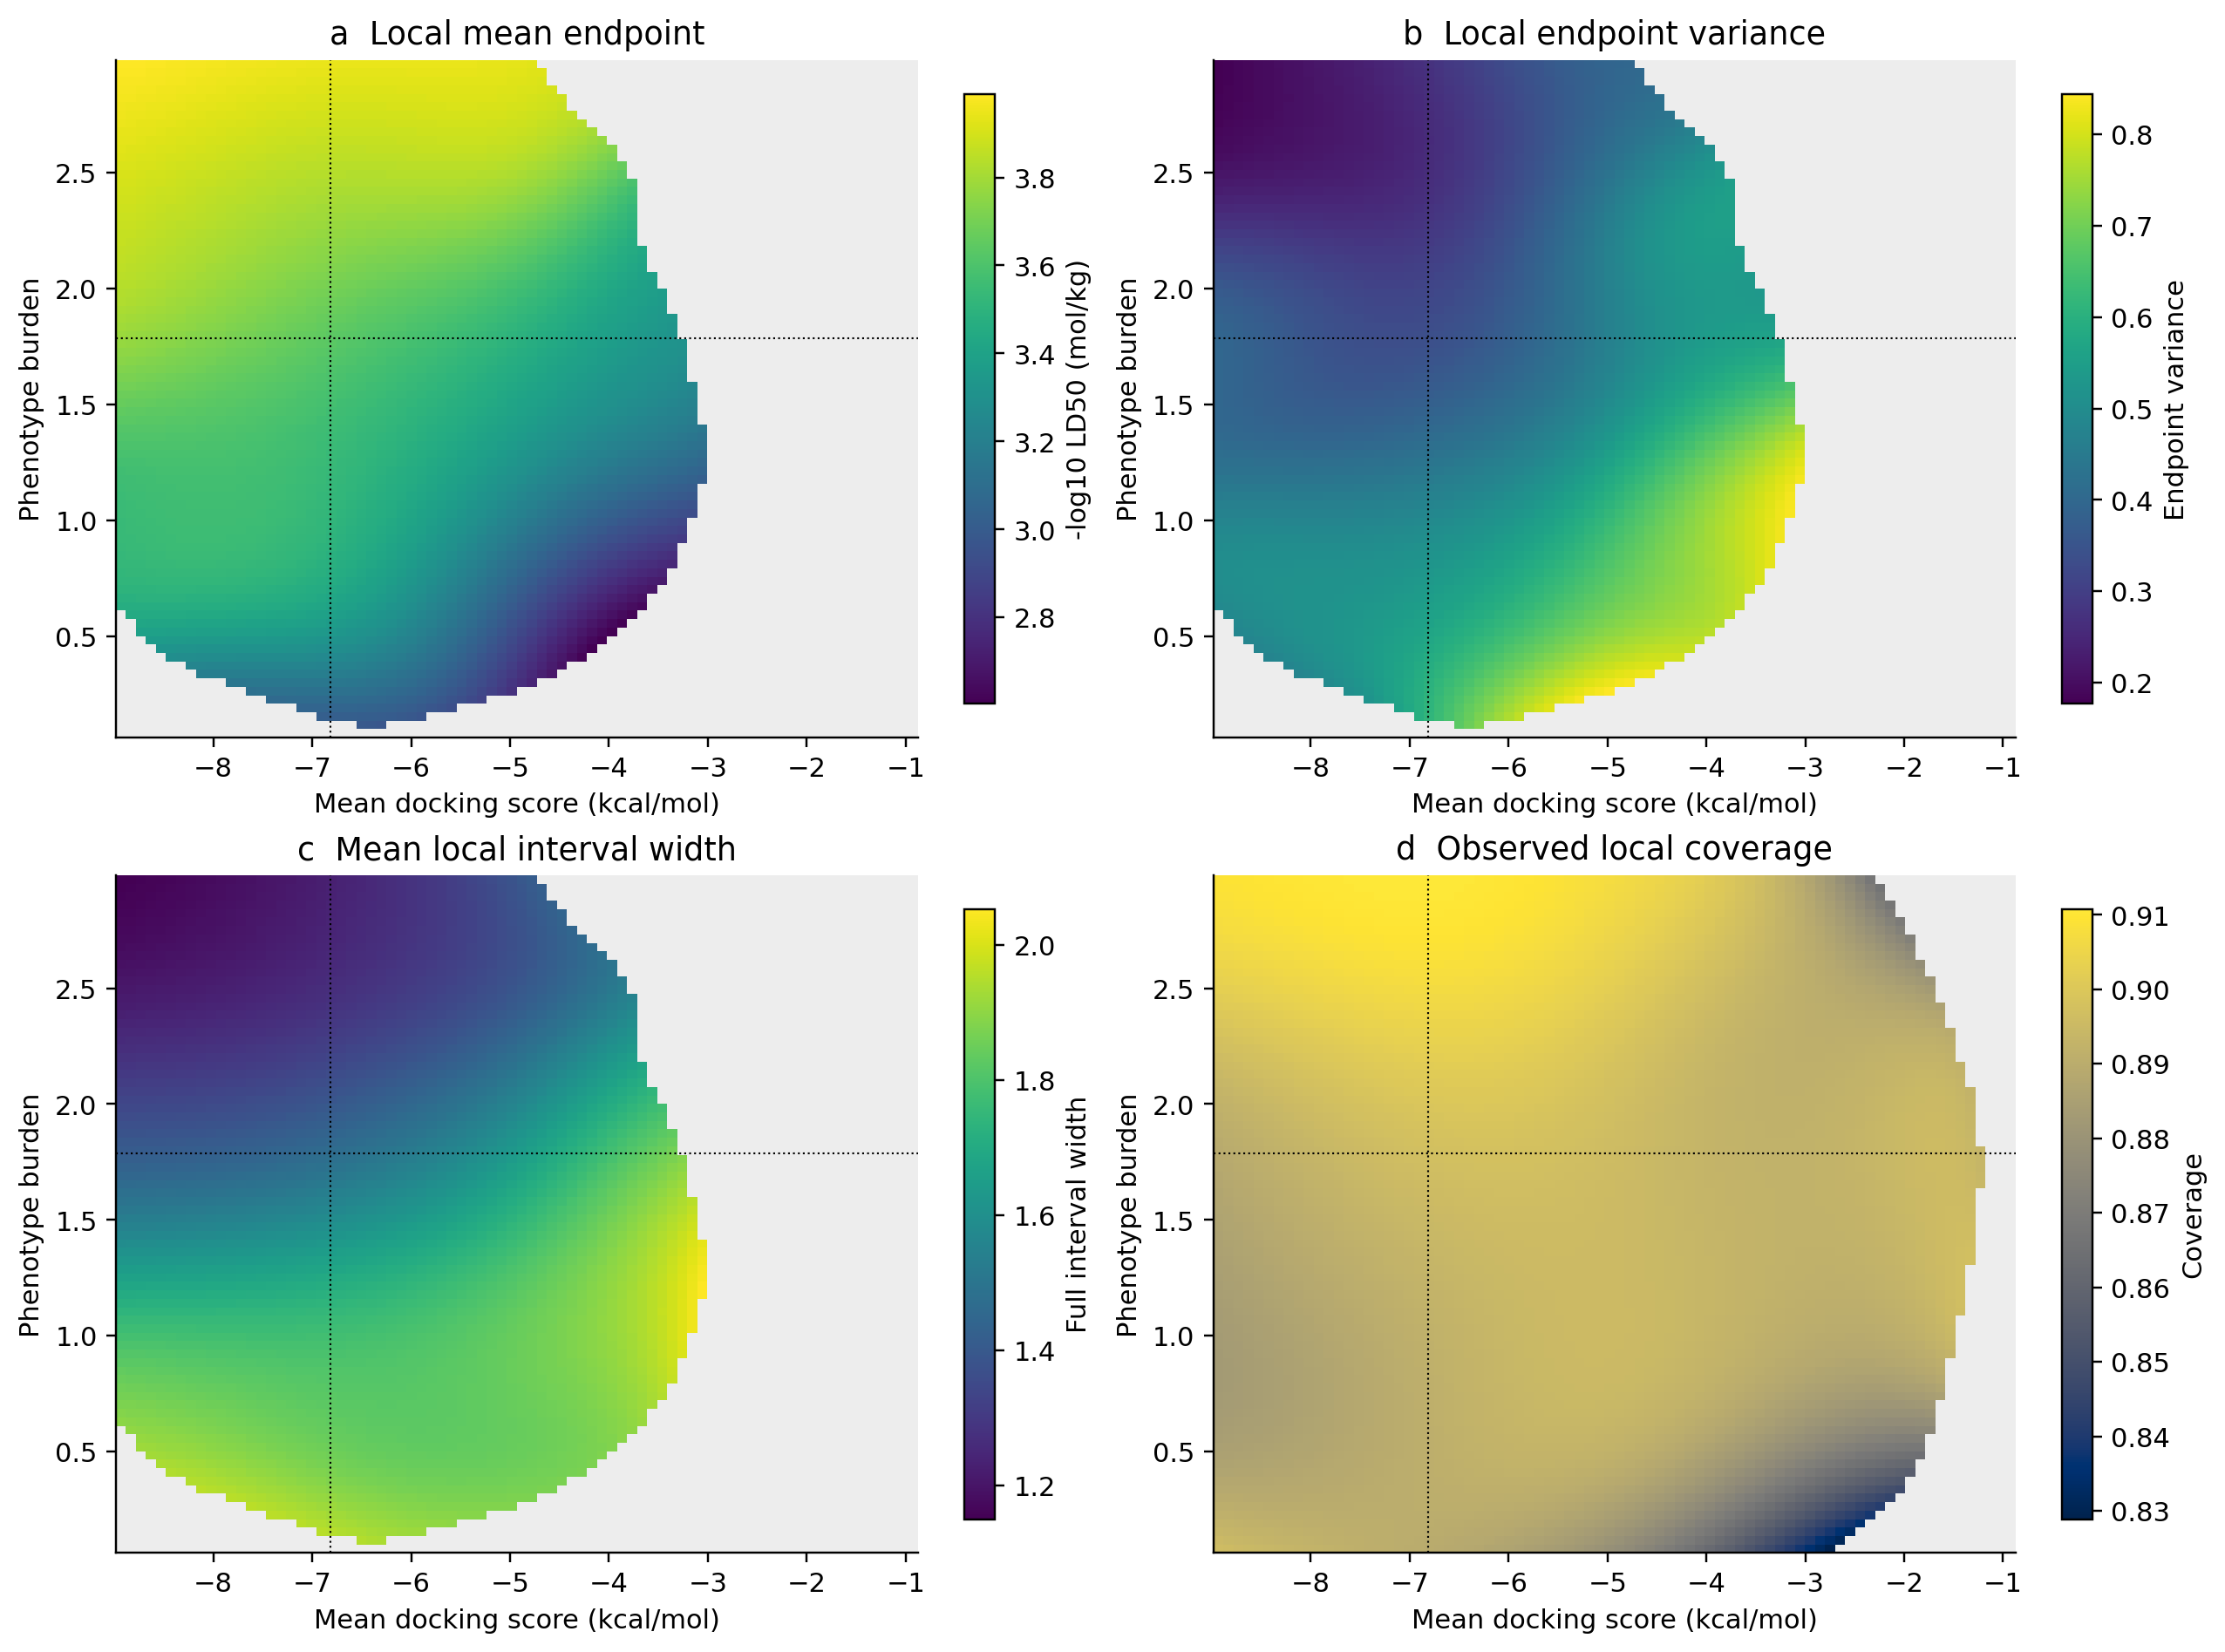

In [2]:
meta=read_json(ADDITIONAL/'figure5_display_metadata.json');display(pd.Series({k:v for k,v in meta.items() if k!='panels'}).to_frame('Value'))
display(pd.DataFrame(meta['panels']).T)
figure('results/repaired/figures/figure5_revised_seed42.png')

## Training-defined quadrant thresholds

Medians are fitted on proper training. Whole-training-cluster bootstrap assesses their stability; it does not select alternative boundaries using the test results.

,seed,coordinate,median,ci_low,ci_high,mean_quadrant_change_probability,fraction_change_probability_above_0.1
0,42,BTox,1.78535,1.74617,1.82350,0.01857,0.06003
1,42,mean44,-6.81591,-6.89435,-6.74545,0.01857,0.06003
2,43,BTox,1.78768,1.74463,1.82690,0.01759,0.05612
3,43,mean44,-6.80341,-6.87503,-6.73409,0.01759,0.05612
4,44,BTox,1.77513,1.73852,1.81396,0.01747,0.05404
5,44,mean44,-6.78864,-6.84545,-6.72045,0.01747,0.05404
6,45,BTox,1.78506,1.74338,1.82000,0.01258,0.03759
7,45,mean44,-6.78636,-6.83864,-6.72955,0.01258,0.03759
8,46,BTox,1.77076,1.73725,1.80911,0.01762,0.05176
9,46,mean44,-6.79318,-6.85227,-6.72727,0.01762,0.05176


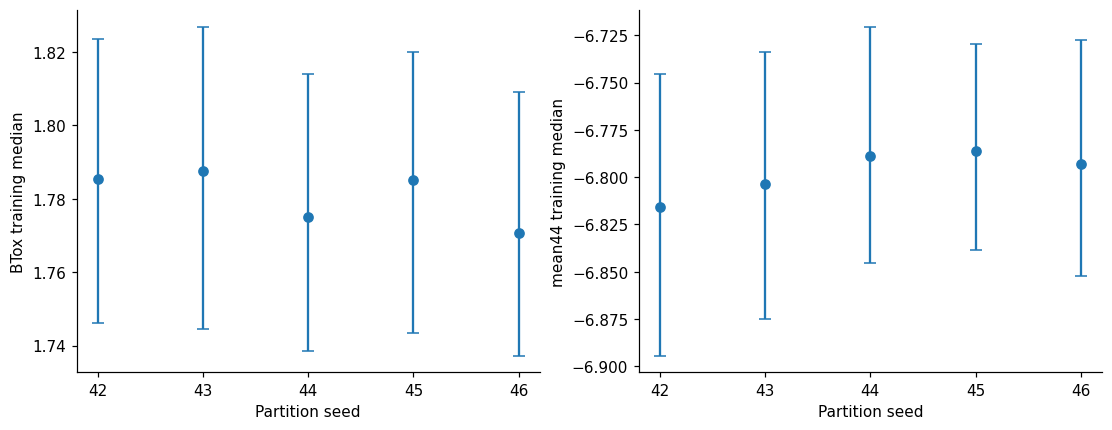

In [3]:
thresholds=additional('quadrant_threshold_bootstrap');display(thresholds)
fig,axs=plt.subplots(1,2,figsize=(10,3.8),layout='constrained')
for ax,name in zip(axs,['BTox','mean44']):
    g=thresholds[thresholds.coordinate.eq(name)]
    ax.errorbar(g.seed,g['median'],yerr=np.vstack([g['median']-g.ci_low,g.ci_high-g['median']]),fmt='o',capsize=4)
    ax.set(xticks=range(42,47),xlabel='Partition seed',ylabel=name+' training median')
finish(fig,'quadrant_threshold_stability')

,quadrant,n,clusters,joint_width,pheno_width,mie_width,coverage,coverage_ci_low,coverage_ci_high,interval_lt_global_n
0,Pheno+ MIE+,786,431,1.24724,1.39203,1.48230,0.89822,0.86577,0.92488,777
1,Pheno+ MIE-,534,290,1.41909,1.42151,1.61039,0.89888,0.85910,0.93124,490
2,Pheno- MIE+,464,329,1.69973,1.80262,1.49085,0.88793,0.85046,0.92055,214
3,Pheno- MIE-,748,528,1.79644,1.88436,1.65132,0.89037,0.86667,0.91358,186


,seed,quadrant,n,n_narrower,fraction,wilson_low,wilson_high,ci_low,ci_high
0,42,Pheno+ MIE+,786,777,0.98855,0.97838,0.99396,0.97730,0.99627
1,42,Pheno+ MIE-,534,490,0.91760,0.89119,0.93805,0.88152,0.94624
2,42,Pheno- MIE+,464,214,0.46121,0.41635,0.50670,0.40224,0.51576
3,42,Pheno- MIE-,748,186,0.24866,0.21902,0.28087,0.20955,0.29161
4,43,Pheno+ MIE+,760,755,0.99342,0.98469,0.99719,0.98357,1.00000
5,43,Pheno+ MIE-,554,419,0.75632,0.71888,0.79022,0.69929,0.81160
6,43,Pheno- MIE+,441,265,0.60091,0.55452,0.64555,0.54439,0.65618
7,43,Pheno- MIE-,704,157,0.22301,0.19381,0.25522,0.17987,0.26967
8,44,Pheno+ MIE+,830,816,0.98313,0.97189,0.98993,0.96985,0.99380
9,44,Pheno+ MIE-,425,277,0.65176,0.60529,0.69552,0.58100,0.71616


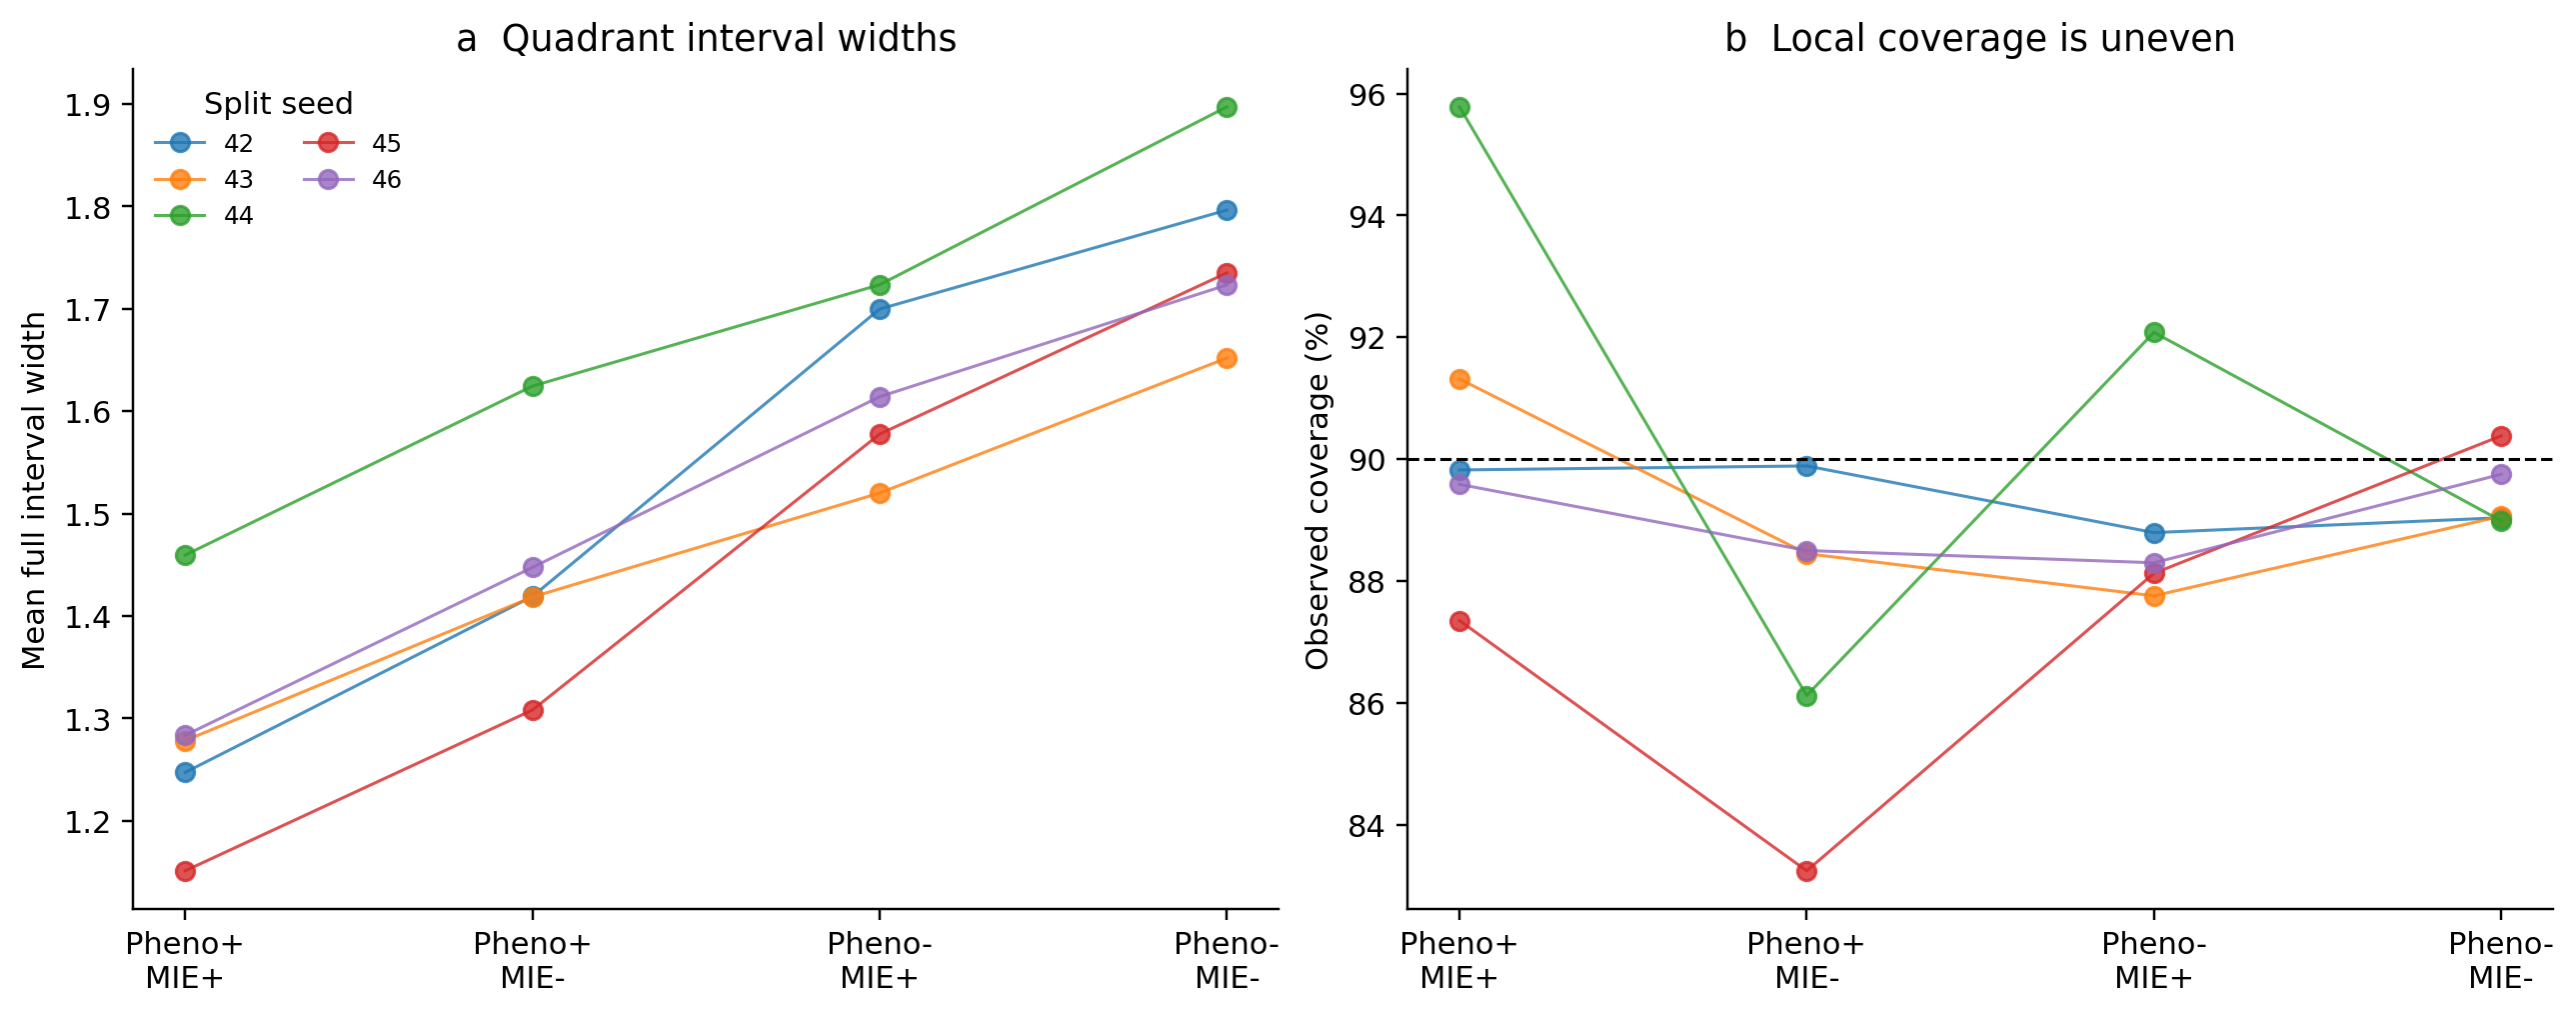

In [4]:
display(table('tables/table3_primary_quadrants.csv'))
display(additional('narrower_interval_confidence'))
figure('results/repaired/figures/quadrant_robustness.png')

## Interpretation

The ordering of widths across quadrants persists; coverage is uneven. Narrower-than-global counts are descriptive. Wilson intervals assume independent Bernoulli observations; cluster-bootstrap intervals are also provided because compounds are grouped.